# PHẦN IV: TĂNG CƯỜNG DỮ LIỆU CÓ MỤC TIÊU & HUẤN LUYỆN LẠI (TARGETED AUGMENTATION + RETRAIN)

**Bối cảnh:** Ở Phần III (Bước 4 - Confusion Matrix) của notebook `s3_ChoosingModel`, model tốt nhất là **CNN 2D (4 Conv)** đạt Test Accuracy = **91.57%**, nhưng vẫn nhầm nhiều ở nhóm áo mặc trên người.

**Số liệu yếu nhất rút ra từ Phần III:**
- `Shirt`: Recall chỉ **0.6493** (F1 = 0.7372) - kém nhất. Hay bị đoán nhầm thành `T-shirt/top` (171), `Pullover` (148), `Coat` (130).
- `Coat`: F1 = 0.8659 (nhầm với `Pullover` 85, `Dress` 41).
- `Pullover`: Precision = 0.8244 (nhiều lớp khác bị đoán nhầm thành `Pullover`).
- `T-shirt/top`: F1 = 0.8757 (nhầm qua lại với `Shirt`).

**Ý tưởng:** 4 lớp áo trên `{T-shirt/top, Pullover, Coat, Shirt}` nhìn rất giống nhau nên model khó phân biệt. Ta sẽ:
1. **Tăng cường có mục tiêu (Targeted Augmentation):** Chỉ áp dụng phép biến đổi MẠNH hơn cho 4 lớp khó này, các lớp dễ giữ phép biến đổi nhẹ như cũ.
2. **Lấy mẫu lặp (Oversampling):** Nhân bản thêm mẫu của các lớp khó (lớp càng yếu nhân càng nhiều) để mỗi epoch model nhìn thấy chúng nhiều lần với các biến thể khác nhau.
3. **Huấn luyện lại** đúng kiến trúc model tốt nhất (CNN 2D 4 Conv) và so sánh với mốc 91.57%.

**Lưu ý:** Notebook này dùng cùng cách chia 60/20/20 với `random_state=42` như Phần I, nên **tập Test giống hệt** - so sánh công bằng với baseline.

## Bước 1: Import thư viện và cấu hình tăng cường có mục tiêu

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Hệ số nhân bản (oversampling) cho từng lớp khó, suy ra từ Confusion Matrix Phần III.
# Lớp càng yếu (Recall càng thấp) thì nhân bản càng nhiều.
#   6 = Shirt    (yếu nhất, Recall 0.65) -> x4
#   4 = Coat     (F1 0.87)               -> x3
#   0 = T-shirt  (F1 0.88)               -> x2
#   2 = Pullover (Precision 0.82)        -> x2
OVERSAMPLE = {6: 4, 4: 3, 0: 2, 2: 2}
HARD_CLASSES = set(OVERSAMPLE.keys())

# Mốc baseline lấy từ Phần III (notebook s3) để so sánh sau khi huấn luyện lại.
BASELINE_TEST_ACC = 0.9157
BASELINE_SHIRT_RECALL = 0.6493

print("Cac lop kho se duoc tang cuong manh:", [class_names[c] for c in sorted(HARD_CLASSES)])
print("He so nhan ban:", {class_names[k]: v for k, v in OVERSAMPLE.items()})

Cac lop kho se duoc tang cuong manh: ['T-shirt/top', 'Pullover', 'Coat', 'Shirt']
He so nhan ban: {'Shirt': 4, 'Coat': 3, 'T-shirt/top': 2, 'Pullover': 2}


## Bước 2: Tải dữ liệu và chia tập giống hệt Phần I (cùng `random_state=42`)
Gộp 70,000 ảnh rồi chia Stratified 60/20/20. Vì cùng seed nên tập Train/Validation/Test trùng khớp với các phần trước, đảm bảo so sánh công bằng.

In [2]:
# Tải dữ liệu thô (transform=None: chỉ lấy pixel gốc dạng uint8 trong .data)
raw_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=None)
raw_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=None)

# Gộp toàn bộ 70,000 ảnh. Thứ tự gộp khớp với cách dùng ConcatDataset ở Phần I.
all_images = torch.cat([raw_train.data, raw_test.data], dim=0)      # uint8 [70000, 28, 28]
all_labels = torch.cat([raw_train.targets, raw_test.targets], dim=0)  # int64 [70000]
labels_np = all_labels.numpy()
all_indices = np.arange(len(all_labels))

# Lần cắt 1: tách 20% làm Test
temp_indices, test_indices, y_temp, y_test = train_test_split(
    all_indices, labels_np, test_size=0.2, stratify=labels_np, random_state=42)
# Lần cắt 2: phần còn lại chia thành Train (60%) và Validation (20%)
train_indices, val_indices, _, _ = train_test_split(
    temp_indices, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(f"Train: {len(train_indices)} | Validation: {len(val_indices)} | Test: {len(test_indices)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.5MB/s]


Train: 42000 | Validation: 14000 | Test: 14000


## Bước 3: Định nghĩa hai mức tăng cường (nhẹ cho lớp dễ, mạnh cho lớp khó)
- **`normal_transform` (lớp dễ):** lật ngang + xoay nhẹ 10 độ - giống Phần I.
- **`strong_transform` (lớp khó):** thêm phép dịch chuyển, phóng to/thu nhỏ (`RandomAffine`) và che ngẫu nhiên một vùng nhỏ (`RandomErasing`). Buộc model học các chi tiết phân biệt (tay áo, cổ áo) thay vì học vẹt hình dáng chung.
- **`eval_transform` (Validation/Test):** giữ nguyên ảnh gốc, chỉ chuẩn hóa về [-1, 1] để chấm điểm khách quan.

In [3]:
normal_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

strong_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.12)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

## Bước 4: Dataset tự chọn phép biến đổi theo lớp + nhân bản mẫu khó
`TargetedAugDataset` nhận một danh sách chỉ số (có thể lặp lại). Với mỗi ảnh, nếu nhãn thuộc nhóm lớp khó thì dùng `strong_transform`, ngược lại dùng `normal_transform`. Vì mỗi lần lấy mẫu phép biến đổi sinh ngẫu nhiên khác nhau, các bản nhân bản KHÔNG bị trùng lặp y hệt.

In [4]:
class TargetedAugDataset(Dataset):
    def __init__(self, images, labels, indices, normal_tf, hard_tf, hard_classes):
        self.images = images              # uint8 [N, 28, 28]
        self.labels = labels              # int64 [N]
        self.indices = list(indices)      # danh sach chi so (co the lap lai de oversample)
        self.normal_tf = normal_tf
        self.hard_tf = hard_tf
        self.hard_classes = set(hard_classes)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        label = int(self.labels[idx])
        img = Image.fromarray(self.images[idx].numpy(), mode='L')  # 28x28 -> PIL grayscale
        tf = self.hard_tf if label in self.hard_classes else self.normal_tf
        return tf(img), label

In [5]:
# Xay dung danh sach chi so Train co nhan ban cho cac lop kho
oversampled_indices = []
for idx in train_indices:
    factor = OVERSAMPLE.get(int(all_labels[idx]), 1)
    oversampled_indices.extend([idx] * factor)

# In phan phoi lop truoc va sau khi nhan ban
base_counts = Counter(int(all_labels[i]) for i in train_indices)
aug_counts = Counter(int(all_labels[i]) for i in oversampled_indices)
print("Phan phoi lop trong tap Train (truoc -> sau oversampling):")
for c in range(10):
    mark = "  <== tang cuong" if c in HARD_CLASSES else ""
    print(f"  {class_names[c]:<12}: {base_counts[c]:>6} -> {aug_counts[c]:>6}{mark}")
print(f"Tong so mau Train: {len(train_indices)} -> {len(oversampled_indices)}")

# Tao 3 dataset + DataLoader
train_dataset = TargetedAugDataset(all_images, all_labels, oversampled_indices,
                                   normal_transform, strong_transform, HARD_CLASSES)
val_dataset = TargetedAugDataset(all_images, all_labels, val_indices,
                                 eval_transform, eval_transform, set())
test_dataset = TargetedAugDataset(all_images, all_labels, test_indices,
                                  eval_transform, eval_transform, set())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("Da tao xong DataLoader.")

Phan phoi lop trong tap Train (truoc -> sau oversampling):
  T-shirt/top :   4200 ->   8400  <== tang cuong
  Trouser     :   4200 ->   4200
  Pullover    :   4200 ->   8400  <== tang cuong
  Dress       :   4200 ->   4200
  Coat        :   4200 ->  12600  <== tang cuong
  Sandal      :   4200 ->   4200
  Shirt       :   4200 ->  16800  <== tang cuong
  Sneaker     :   4200 ->   4200
  Bag         :   4200 ->   4200
  Ankle boot  :   4200 ->   4200
Tong so mau Train: 42000 -> 71400
Da tao xong DataLoader.


## Bước 5: Định nghĩa lại model tốt nhất (CNN 2D - 4 lớp Conv)
Giữ nguyên kiến trúc đã thắng ở Phần II để chỉ đo tác động của việc tăng cường dữ liệu.

In [6]:
class CNN2D(nn.Module):
    def __init__(self):
        super(CNN2D, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model = CNN2D()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tong so tham so trainable: {total_params:,}")

Tong so tham so trainable: 468,202


## Bước 6: Hàm huấn luyện (có lưu lại trọng số tốt nhất theo Validation)
Khác với Phần II, vòng huấn luyện ở đây ghi nhớ trọng số tại epoch có **Validation Accuracy cao nhất** và nạp lại trước khi đo trên Test, tránh lấy nhầm epoch bị dao động xấu ở cuối.

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def fit_model(model, train_loader, val_loader, epochs=10, lr=0.001, weight_decay=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    total_time = time.time() - start
    if best_state is not None:
        model.load_state_dict(best_state)  # nap lai trong so tot nhat
    print(f"Hoan thanh trong {total_time:.2f}s. Validation Accuracy tot nhat: {best_val_acc*100:.2f}%")
    return history, total_time, best_val_acc

## Bước 7: Huấn luyện lại model với dữ liệu đã tăng cường

In [12]:
print("--- HUAN LUYEN LAI CNN 2D VOI TARGETED AUGMENTATION ---")
model = CNN2D()
history, train_time, best_val_acc = fit_model(model, train_loader, valid_loader,
                                              epochs=10, lr=0.001, weight_decay=1e-4)

--- HUAN LUYEN LAI CNN 2D VOI TARGETED AUGMENTATION ---
Training on device: cuda


/tmp/ipykernel_3038/3629907279.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode='L')  # 28x28 -> PIL grayscale


Epoch [1/10] - Train Loss: 0.7991, Train Acc: 68.14% | Val Loss: 0.3713, Val Acc: 86.11%
Epoch [2/10] - Train Loss: 0.6038, Train Acc: 76.61% | Val Loss: 0.3391, Val Acc: 88.29%
Epoch [3/10] - Train Loss: 0.5364, Train Acc: 79.59% | Val Loss: 0.3329, Val Acc: 88.65%
Epoch [4/10] - Train Loss: 0.4982, Train Acc: 81.07% | Val Loss: 0.3030, Val Acc: 89.35%
Epoch [5/10] - Train Loss: 0.4688, Train Acc: 82.16% | Val Loss: 0.3340, Val Acc: 88.44%
Epoch [6/10] - Train Loss: 0.4437, Train Acc: 83.31% | Val Loss: 0.2842, Val Acc: 89.97%
Epoch [7/10] - Train Loss: 0.4265, Train Acc: 83.95% | Val Loss: 0.2693, Val Acc: 90.46%
Epoch [8/10] - Train Loss: 0.4122, Train Acc: 84.46% | Val Loss: 0.3251, Val Acc: 89.47%
Epoch [9/10] - Train Loss: 0.3994, Train Acc: 85.34% | Val Loss: 0.2869, Val Acc: 90.51%
Epoch [10/10] - Train Loss: 0.3872, Train Acc: 85.68% | Val Loss: 0.2808, Val Acc: 90.59%
Hoan thanh trong 411.16s. Validation Accuracy tot nhat: 90.59%


In [21]:
print("--- Thu lai voi 15 epochs ---")
model = CNN2D()
history, train_time, best_val_acc = fit_model(model, train_loader, valid_loader,
                                              epochs=15, lr=0.001, weight_decay=1e-4)

--- Thu lai voi 15 epochs ---
Training on device: cuda


/tmp/ipykernel_3038/3629907279.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode='L')  # 28x28 -> PIL grayscale


Epoch [1/15] - Train Loss: 0.8396, Train Acc: 66.01% | Val Loss: 0.4058, Val Acc: 85.01%
Epoch [2/15] - Train Loss: 0.6287, Train Acc: 75.25% | Val Loss: 0.3447, Val Acc: 87.61%
Epoch [3/15] - Train Loss: 0.5623, Train Acc: 78.13% | Val Loss: 0.3565, Val Acc: 87.89%
Epoch [4/15] - Train Loss: 0.5231, Train Acc: 79.86% | Val Loss: 0.4316, Val Acc: 85.79%
Epoch [5/15] - Train Loss: 0.4914, Train Acc: 81.44% | Val Loss: 0.3155, Val Acc: 88.39%
Epoch [6/15] - Train Loss: 0.4622, Train Acc: 82.61% | Val Loss: 0.2761, Val Acc: 90.26%
Epoch [7/15] - Train Loss: 0.4444, Train Acc: 83.45% | Val Loss: 0.2881, Val Acc: 90.12%
Epoch [8/15] - Train Loss: 0.4223, Train Acc: 84.14% | Val Loss: 0.3558, Val Acc: 87.92%
Epoch [9/15] - Train Loss: 0.4065, Train Acc: 84.97% | Val Loss: 0.2788, Val Acc: 90.36%
Epoch [10/15] - Train Loss: 0.3929, Train Acc: 85.31% | Val Loss: 0.2585, Val Acc: 90.72%
Epoch [11/15] - Train Loss: 0.3763, Train Acc: 86.06% | Val Loss: 0.2745, Val Acc: 90.88%
Epoch [12/15] - Tra

## Bước 8: Đo trên tập Test và so sánh với baseline (91.57%)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_all_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_labels_list, all_images_list = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            _, preds = outputs.max(1)
            all_preds.append(preds.cpu())
            all_labels_list.append(labels)
            all_images_list.append(images.cpu())
    return torch.cat(all_preds), torch.cat(all_labels_list), torch.cat(all_images_list)


y_pred, y_true, test_images = get_all_predictions(model, test_loader, device)
new_test_acc = (y_pred == y_true).float().mean().item()

print("="*60)
print(f"{'Test Accuracy baseline (Phan III)':<40}: {BASELINE_TEST_ACC*100:.2f}%")
print(f"{'Test Accuracy sau augmentation':<40}: {new_test_acc*100:.2f}%")
print(f"{'Chenh lech':<40}: {(new_test_acc - BASELINE_TEST_ACC)*100:+.2f}%")
print("="*60)

/tmp/ipykernel_3038/3629907279.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode='L')  # 28x28 -> PIL grayscale


Test Accuracy baseline (Phan III)       : 91.57%
Test Accuracy sau augmentation          : 90.48%
Chenh lech                              : -1.09%


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#test lai khi train 15 epochs
def get_all_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_labels_list, all_images_list = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            _, preds = outputs.max(1)
            all_preds.append(preds.cpu())
            all_labels_list.append(labels)
            all_images_list.append(images.cpu())
    return torch.cat(all_preds), torch.cat(all_labels_list), torch.cat(all_images_list)


y_pred, y_true, test_images = get_all_predictions(model, test_loader, device)
new_test_acc = (y_pred == y_true).float().mean().item()

print("="*60)
print(f"{'Test Accuracy baseline (Phan III)':<40}: {BASELINE_TEST_ACC*100:.2f}%")
print(f"{'Test Accuracy sau augmentation':<40}: {new_test_acc*100:.2f}%")
print(f"{'Chenh lech':<40}: {(new_test_acc - BASELINE_TEST_ACC)*100:+.2f}%")
print("="*60)

/tmp/ipykernel_3038/3629907279.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode='L')  # 28x28 -> PIL grayscale


Test Accuracy baseline (Phan III)       : 91.57%
Test Accuracy sau augmentation          : 91.59%
Chenh lech                              : +0.02%


## Bước 9: Biểu đồ Loss & Accuracy (Train vs Validation)

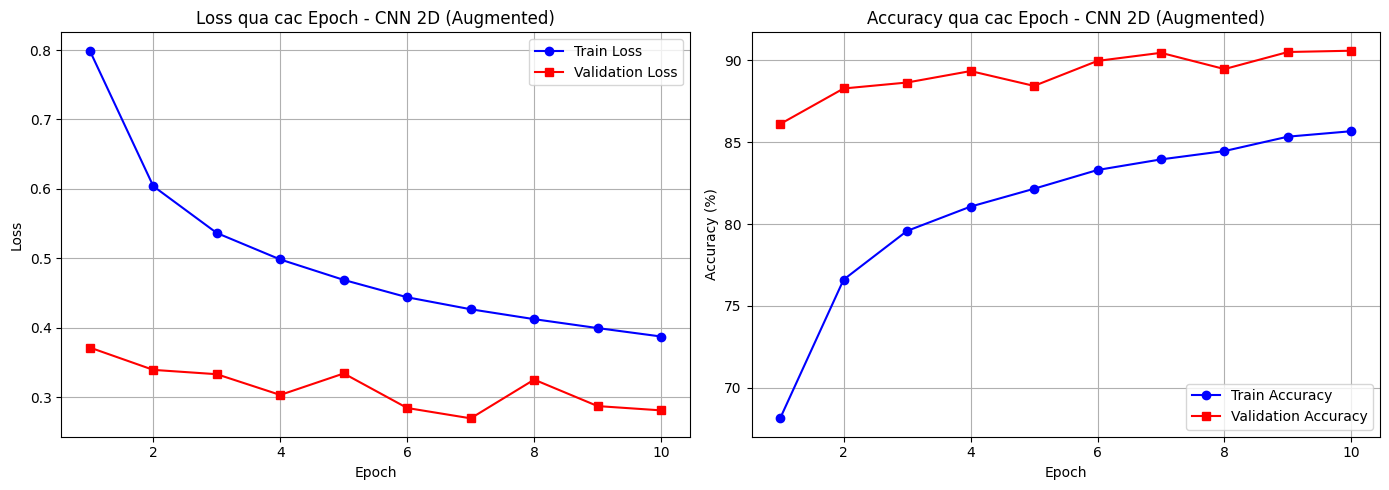

In [14]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Loss qua cac Epoch - CNN 2D (Augmented)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, [a*100 for a in history['val_acc']], 'r-s', label='Validation Accuracy')
plt.title('Accuracy qua cac Epoch - CNN 2D (Augmented)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

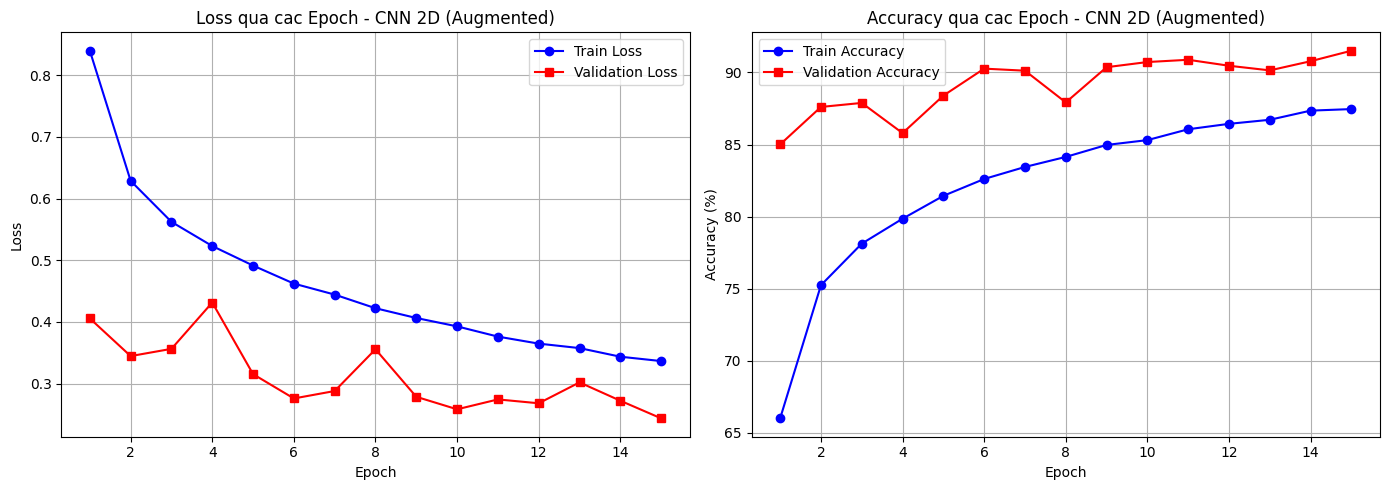

In [23]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Loss qua cac Epoch - CNN 2D (Augmented)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, [a*100 for a in history['val_acc']], 'r-s', label='Validation Accuracy')
plt.title('Accuracy qua cac Epoch - CNN 2D (Augmented)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bước 10: Confusion Matrix sau khi tăng cường
So sánh với ma trận ở Phần III: các ô nhầm lẫn của nhóm `Shirt / T-shirt / Pullover / Coat` được kỳ vọng giảm xuống.

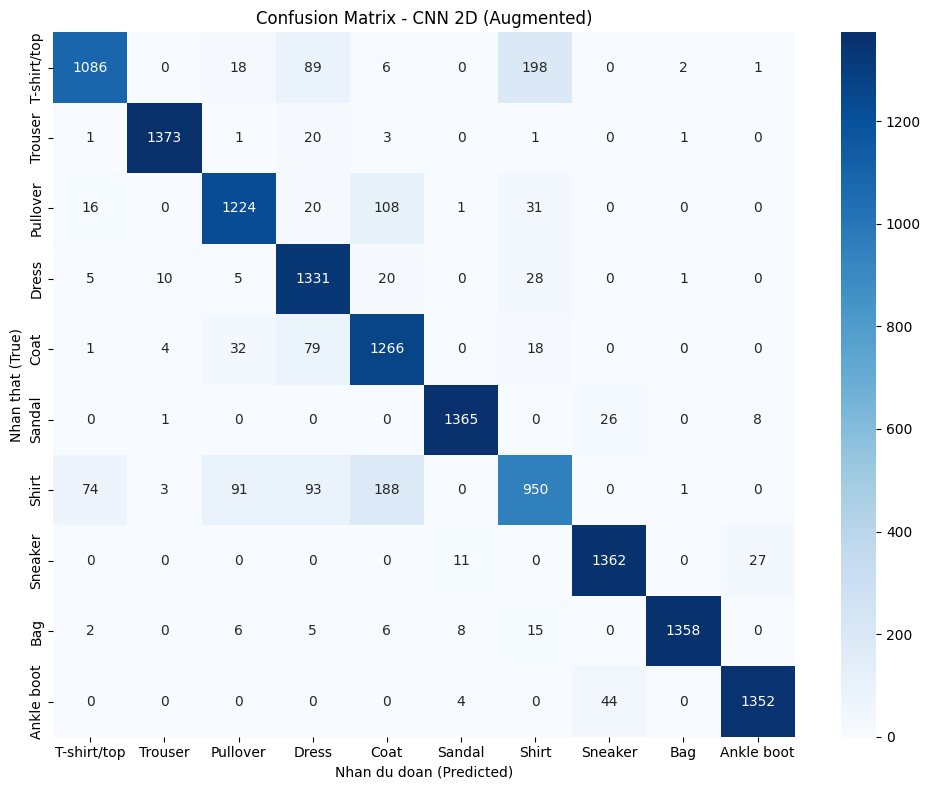

In [15]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(10)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN 2D (Augmented)')
plt.xlabel('Nhan du doan (Predicted)')
plt.ylabel('Nhan that (True)')
plt.tight_layout()
plt.show()

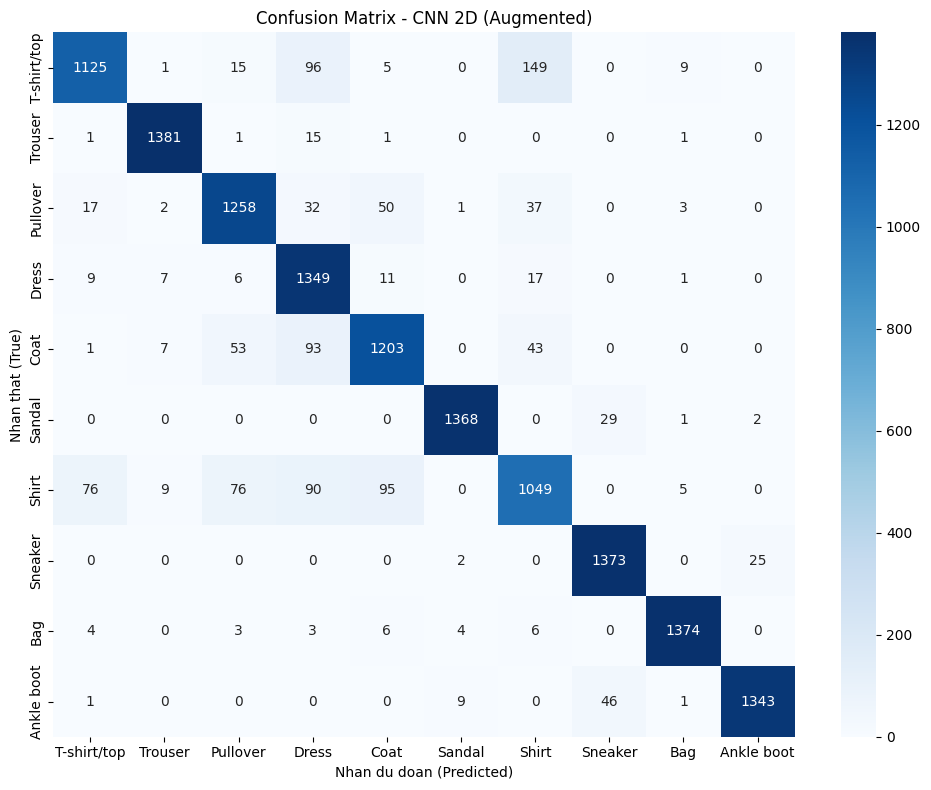

In [24]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(10)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN 2D (Augmented)')
plt.xlabel('Nhan du doan (Predicted)')
plt.ylabel('Nhan that (True)')
plt.tight_layout()
plt.show()

## Bước 11: Classification Report và mức cải thiện của lớp `Shirt`

In [16]:
report = classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                               target_names=class_names, digits=4, zero_division=0)
print("Bao cao phan loai chi tiet - CNN 2D (Augmented)\n")
print(report)

# So sanh rieng Recall cua lop Shirt (lop yeu nhat o Phan III)
report_dict = classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                                    target_names=class_names, digits=4, zero_division=0,
                                    output_dict=True)
new_shirt_recall = report_dict['Shirt']['recall']
print("-"*60)
print(f"Recall lop Shirt: {BASELINE_SHIRT_RECALL:.4f} (baseline) -> {new_shirt_recall:.4f} (augmented) "
      f"[{(new_shirt_recall - BASELINE_SHIRT_RECALL)*100:+.2f}%]")

Bao cao phan loai chi tiet - CNN 2D (Augmented)

              precision    recall  f1-score   support

 T-shirt/top     0.9165    0.7757    0.8402      1400
     Trouser     0.9871    0.9807    0.9839      1400
    Pullover     0.8889    0.8743    0.8815      1400
       Dress     0.8131    0.9507    0.8765      1400
        Coat     0.7927    0.9043    0.8448      1400
      Sandal     0.9827    0.9750    0.9788      1400
       Shirt     0.7655    0.6786    0.7194      1400
     Sneaker     0.9511    0.9729    0.9619      1400
         Bag     0.9963    0.9700    0.9830      1400
  Ankle boot     0.9741    0.9657    0.9699      1400

    accuracy                         0.9048     14000
   macro avg     0.9068    0.9048    0.9040     14000
weighted avg     0.9068    0.9048    0.9040     14000

------------------------------------------------------------
Recall lop Shirt: 0.6493 (baseline) -> 0.6786 (augmented) [+2.93%]


In [25]:
report = classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                               target_names=class_names, digits=4, zero_division=0)
print("Bao cao phan loai chi tiet - CNN 2D (Augmented)\n")
print(report)

# So sanh rieng Recall cua lop Shirt (lop yeu nhat o Phan III)
report_dict = classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                                    target_names=class_names, digits=4, zero_division=0,
                                    output_dict=True)
new_shirt_recall = report_dict['Shirt']['recall']
print("-"*60)
print(f"Recall lop Shirt: {BASELINE_SHIRT_RECALL:.4f} (baseline) -> {new_shirt_recall:.4f} (augmented) "
      f"[{(new_shirt_recall - BASELINE_SHIRT_RECALL)*100:+.2f}%]")

Bao cao phan loai chi tiet - CNN 2D (Augmented)

              precision    recall  f1-score   support

 T-shirt/top     0.9117    0.8036    0.8542      1400
     Trouser     0.9815    0.9864    0.9840      1400
    Pullover     0.8909    0.8986    0.8947      1400
       Dress     0.8039    0.9636    0.8765      1400
        Coat     0.8775    0.8593    0.8683      1400
      Sandal     0.9884    0.9771    0.9828      1400
       Shirt     0.8063    0.7493    0.7767      1400
     Sneaker     0.9482    0.9807    0.9642      1400
         Bag     0.9849    0.9814    0.9832      1400
  Ankle boot     0.9803    0.9593    0.9697      1400

    accuracy                         0.9159     14000
   macro avg     0.9174    0.9159    0.9154     14000
weighted avg     0.9174    0.9159    0.9154     14000

------------------------------------------------------------
Recall lop Shirt: 0.6493 (baseline) -> 0.7493 (augmented) [+10.00%]


## Bước 12: Một số ảnh vẫn bị nhận diện nhầm

Tong so anh bi nham: 1333 / 14000 (9.52%)


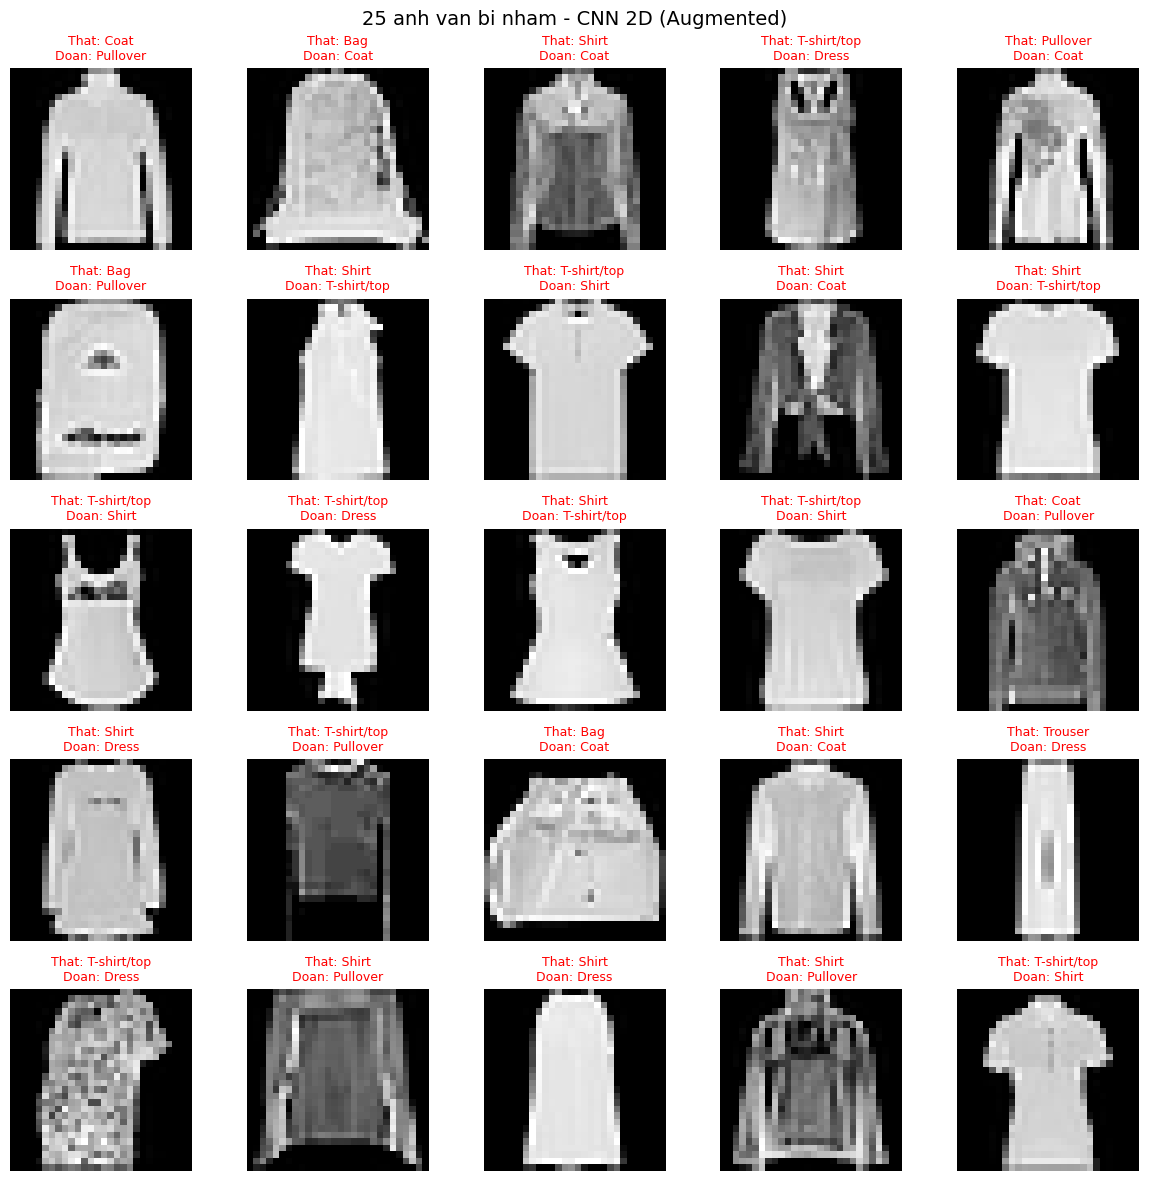

In [17]:
wrong_idx = (y_pred != y_true).nonzero(as_tuple=True)[0]
print(f"Tong so anh bi nham: {len(wrong_idx)} / {len(y_true)} "
      f"({len(wrong_idx)/len(y_true)*100:.2f}%)")

n_show = min(25, len(wrong_idx))
plt.figure(figsize=(12, 12))
for i in range(n_show):
    idx = wrong_idx[i].item()
    img = test_images[idx].squeeze() * 0.5 + 0.5  # bo chuan hoa [-1,1] -> [0,1]
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"That: {class_names[y_true[idx]]}\nDoan: {class_names[y_pred[idx]]}",
              color='red', fontsize=9)
plt.suptitle('25 anh van bi nham - CNN 2D (Augmented)', fontsize=14)
plt.tight_layout()
plt.show()

Tong so anh bi nham: 1177 / 14000 (8.41%)


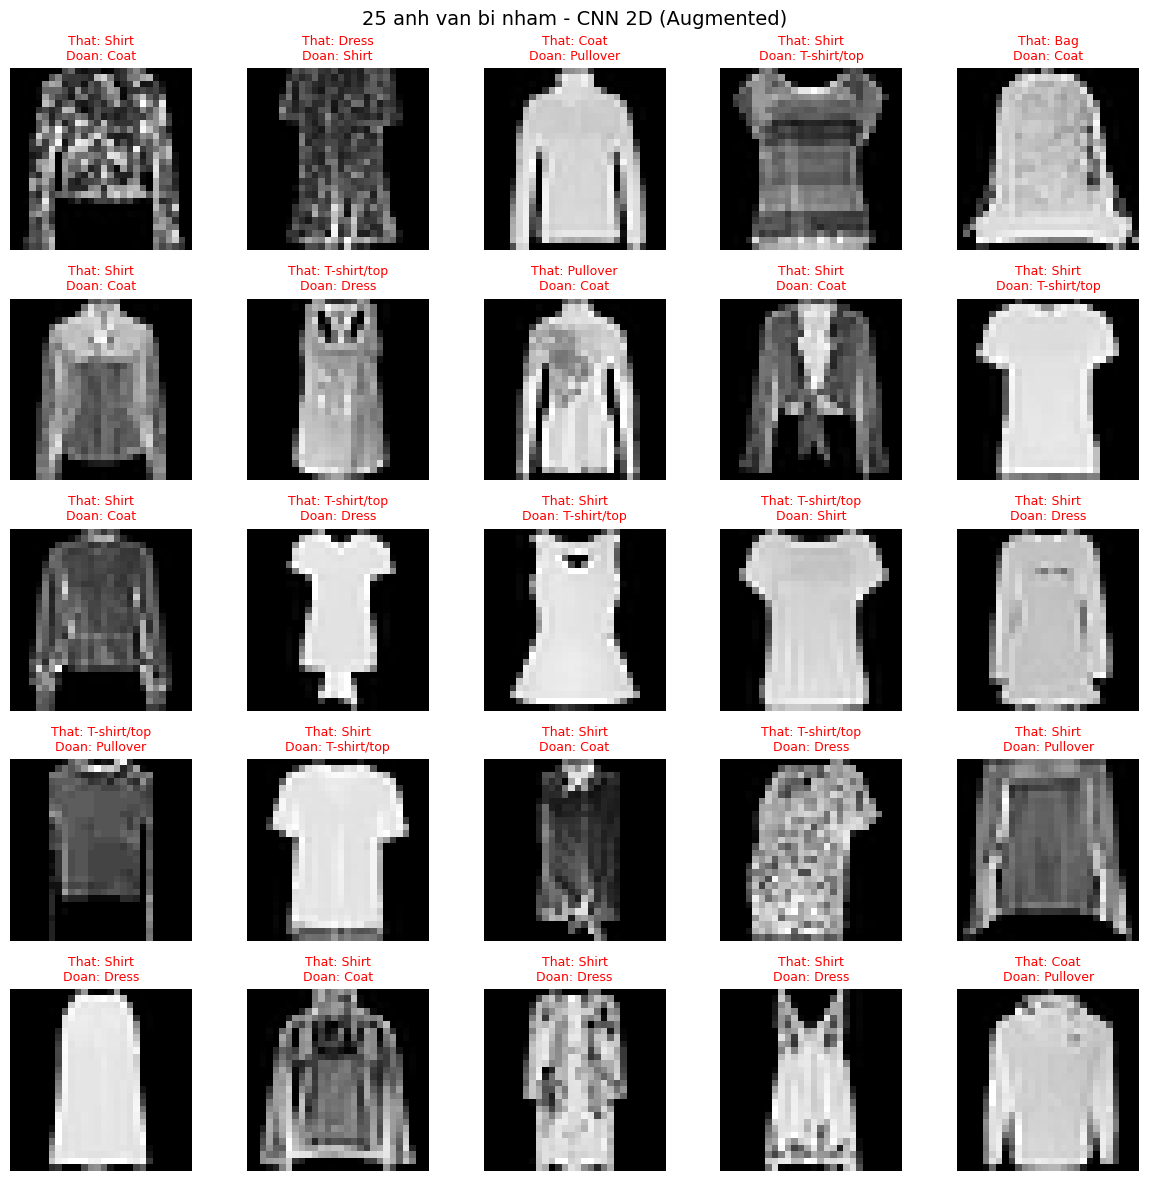

In [26]:
wrong_idx = (y_pred != y_true).nonzero(as_tuple=True)[0]
print(f"Tong so anh bi nham: {len(wrong_idx)} / {len(y_true)} "
      f"({len(wrong_idx)/len(y_true)*100:.2f}%)")

n_show = min(25, len(wrong_idx))
plt.figure(figsize=(12, 12))
for i in range(n_show):
    idx = wrong_idx[i].item()
    img = test_images[idx].squeeze() * 0.5 + 0.5  # bo chuan hoa [-1,1] -> [0,1]
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"That: {class_names[y_true[idx]]}\nDoan: {class_names[y_pred[idx]]}",
              color='red', fontsize=9)
plt.suptitle('25 anh van bi nham - CNN 2D (Augmented)', fontsize=14)
plt.tight_layout()
plt.show()

## Bước 13: Top các cặp lớp còn bị nhầm nhiều nhất

In [18]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = [(cm_off[i, j], class_names[i], class_names[j])
         for i in range(len(class_names))
         for j in range(len(class_names))
         if cm_off[i, j] > 0]
pairs.sort(reverse=True)

print("Top 10 cap bi nham nhieu nhat sau augmentation (Nhan that -> Nhan doan):")
for count, t, p in pairs[:10]:
    print(f"  {t:<12} -> {p:<12}: {count} anh")

Top 10 cap bi nham nhieu nhat sau augmentation (Nhan that -> Nhan doan):
  T-shirt/top  -> Shirt       : 198 anh
  Shirt        -> Coat        : 188 anh
  Pullover     -> Coat        : 108 anh
  Shirt        -> Dress       : 93 anh
  Shirt        -> Pullover    : 91 anh
  T-shirt/top  -> Dress       : 89 anh
  Coat         -> Dress       : 79 anh
  Shirt        -> T-shirt/top : 74 anh
  Ankle boot   -> Sneaker     : 44 anh
  Coat         -> Pullover    : 32 anh


In [27]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = [(cm_off[i, j], class_names[i], class_names[j])
         for i in range(len(class_names))
         for j in range(len(class_names))
         if cm_off[i, j] > 0]
pairs.sort(reverse=True)

print("Top 10 cap bi nham nhieu nhat sau augmentation (Nhan that -> Nhan doan):")
for count, t, p in pairs[:10]:
    print(f"  {t:<12} -> {p:<12}: {count} anh")

Top 10 cap bi nham nhieu nhat sau augmentation (Nhan that -> Nhan doan):
  T-shirt/top  -> Shirt       : 149 anh
  T-shirt/top  -> Dress       : 96 anh
  Shirt        -> Coat        : 95 anh
  Coat         -> Dress       : 93 anh
  Shirt        -> Dress       : 90 anh
  Shirt        -> T-shirt/top : 76 anh
  Shirt        -> Pullover    : 76 anh
  Coat         -> Pullover    : 53 anh
  Pullover     -> Coat        : 50 anh
  Ankle boot   -> Sneaker     : 46 anh


## Bước 14: Lưu lại model đã cải thiện
Lưu trọng số (đã nạp epoch tốt nhất) để tái sử dụng cho dự đoán sau này mà không cần huấn luyện lại.

In [19]:
import os

os.makedirs("models", exist_ok=True)
save_path = "models/cnn2d_augmented.pth"
torch.save(model.state_dict(), save_path)
print(f"Da luu model vao: {save_path}")
print("Tai lai bang: model = CNN2D(); model.load_state_dict(torch.load('models/cnn2d_augmented.pth'))")

Da luu model vao: models/cnn2d_augmented.pth
Tai lai bang: model = CNN2D(); model.load_state_dict(torch.load('models/cnn2d_augmented.pth'))


In [29]:
import os

os.makedirs("models", exist_ok=True)
save_path = "models/cnn2d_augmented_15.pth"
torch.save(model.state_dict(), save_path)
print(f"Da luu model vao: {save_path}")
print("Tai lai bang: model = CNN2D(); model.load_state_dict(torch.load('models/cnn2d_augmented_15.pth'))")

Da luu model vao: models/cnn2d_augmented_15.pth
Tai lai bang: model = CNN2D(); model.load_state_dict(torch.load('models/cnn2d_augmented_15.pth'))
